# Question 3

#### Import Libraries

In [1]:
# Question 3: Model Development
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For feature extraction
import re

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
os.makedirs('output', exist_ok=True)


#### Load Cleaned Data

In [2]:
# Load cleaned data from Q1
df = pd.read_csv(r'C:\Users\KHABAZELA\OneDrive\Desktop\Car_prices_ITSCA_Project\Dataset\car_pricing_cleaned.csv')
print("Data loaded. Shape:", df.shape)
df.head(2)

Data loaded. Shape: (169, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1.0,3.0,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,269900.0
1,2.0,3.0,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,330000.0


## 3.1: Machine Learning Problem Statement

### Nature of the Problem
This is a **Regression** problem. We are predicting a continuous numeric value (price in Rands), not a category.

### Target Variable
- **Target (y):** `price` – the car's selling price.

### Input Features (X)
I will use the following predictors identified in Q1 as most important:
- **Numerical:** `enginesize`, `horsepower`, `curbweight`, `carlength`, `carwidth`, `citympg`, `highwaympg`
- **Categorical:** `fueltype` (gas/diesel), `carbody` (sedan/hatchback/etc.), `aspiration` (std/turbo)

### Feature Transformations
- **Extract Make:** I will extract the car brand ( "audi", "bmw") from `CarName` and use it as a category.
- **One-Hot Encoding:** Categorical columns will be converted to numeric (0/1) columns.
- **Scaling:** Numerical columns will be scaled to have mean=0 and std=1 so the model treats all features fairly.

### Extract Car Make from CarName

In [6]:
# Extract make (first word) from CarName
def extract_make(name):
    if isinstance(name, str):
        return name.split()[0]
    return 'unknown'

df['make'] = df['CarName'].apply(extract_make)

# Check unique makes
print("Car makes:")
print(df['make'].value_counts().head(10))

Car makes:
make
toyota        23
mazda         15
nissan        14
honda         12
subaru        10
mitsubishi    10
volvo         10
peugeot        9
dodge          8
volkswagen     7
Name: count, dtype: int64


###  Features and Target

In [7]:
# Define numerical features (from Q1 findings)
numerical_features = ['enginesize', 'horsepower', 'curbweight', 'carlength', 'carwidth', 'citympg', 'highwaympg']

# Define categorical features
categorical_features = ['fueltype', 'aspiration', 'carbody', 'make']

# Target
target = 'price'

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numerical features: ['enginesize', 'horsepower', 'curbweight', 'carlength', 'carwidth', 'citympg', 'highwaympg']
Categorical features: ['fueltype', 'aspiration', 'carbody', 'make']
Target: price


### X (Features) and y (Target)

In [8]:
# Prepare X (features)
X = df[numerical_features + categorical_features].copy()

# Prepare y (target)
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (169, 11)
y shape: (169,)


### One-Hot Encode Categorical Variables

In [9]:
# Convert categorical columns to dummies
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("Original features:", X.shape[1])
print("Features after encoding:", X_encoded.shape[1])
print("\nColumn names:")
print(X_encoded.columns.tolist())

Original features: 11
Features after encoding: 38

Column names:
['enginesize', 'horsepower', 'curbweight', 'carlength', 'carwidth', 'citympg', 'highwaympg', 'fueltype_gas', 'aspiration_turbo', 'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'make_alfa-romero', 'make_audi', 'make_bmw', 'make_buick', 'make_chevrolet', 'make_dodge', 'make_honda', 'make_isuzu', 'make_jaguar', 'make_maxda', 'make_mazda', 'make_mitsubishi', 'make_nissan', 'make_peugeot', 'make_plymouth', 'make_porcshce', 'make_porsche', 'make_renault', 'make_saab', 'make_subaru', 'make_toyota', 'make_vokswagen', 'make_volkswagen', 'make_volvo', 'make_vw']


### Scale Numerical Features

In [10]:
# Scale numerical features only
scaler = StandardScaler()
X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

print("Numerical features scaled.")
print("First 2 rows of final feature set:")
X_encoded.head(2)

Numerical features scaled.
First 2 rows of final feature set:


,enginesize,horsepower,curbweight,carlength,carwidth,citympg,highwaympg,fueltype_gas,aspiration_turbo,carbody_hardtop,...,make_porcshce,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_vokswagen,make_volkswagen,make_volvo,make_vw
0,0.059109,0.156429,-0.041458,-0.451722,-0.867174,-0.636865,-0.524614,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.059109,0.156429,-0.041458,-0.451722,-0.867174,-0.636865,-0.524614,True,False,False,...,False,False,False,False,False,False,False,False,False,False


### Train-Test Split

In [11]:
# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Train/Test ratio:", round(X_train.shape[0]/len(df)*100), "% /", round(X_test.shape[0]/len(df)*100), "%")

Training set size: 135
Test set size: 34
Train/Test ratio: 80 % / 20 %


## 3.2 Train and Compare 3 Models

### Linear Regression (Baseline)

In [14]:
# Model 1: Linear Regression
# from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

print("Linear Regression trained!")
print("Training R²:", round(r2_score(y_train, y_pred_lr_train), 4))
print("Test R²:", round(r2_score(y_test, y_pred_lr_test), 4))

Linear Regression trained!
Training R²: 0.9526
Test R²: 0.8162


### Train Decision Tree

In [16]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt_train = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)

print("Decision Tree trained!")
print("Training R²:", round(r2_score(y_train, y_pred_dt_train), 4))
print("Test R²:", round(r2_score(y_test, y_pred_dt_test), 4))

Decision Tree trained!
Training R²: 0.9933
Test R²: 0.9291


### Train Random Forest

In [17]:
# Model 3: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

print("Random Forest trained!")
print("Training R²:", round(r2_score(y_train, y_pred_rf_train), 4))
print("Test R²:", round(r2_score(y_test, y_pred_rf_test), 4))

Random Forest trained!
Training R²: 0.9876
Test R²: 0.9512


### Calculate All Metrics

In [18]:
# Calculate metrics for all models
models = {
    'Linear Regression': (y_pred_lr_train, y_pred_lr_test),
    'Decision Tree': (y_pred_dt_train, y_pred_dt_test),
    'Random Forest': (y_pred_rf_train, y_pred_rf_test)
}

results = []

for name, (pred_train, pred_test) in models.items():
    results.append({
        'Model': name,
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, pred_train)), 0),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, pred_test)), 0),
        'Train MAE': round(mean_absolute_error(y_train, pred_train), 0),
        'Test MAE': round(mean_absolute_error(y_test, pred_test), 0),
        'Train R²': round(r2_score(y_train, pred_train), 4),
        'Test R²': round(r2_score(y_test, pred_test), 4)
    })

# Create comparison table
comparison_df = pd.DataFrame(results)
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))

MODEL COMPARISON
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression     34063.0    72393.0    25022.0   44131.0    0.9526   0.8162
    Decision Tree     12812.0    44961.0     6039.0   31261.0    0.9933   0.9291
    Random Forest     17446.0    37294.0    12503.0   25250.0    0.9876   0.9512


### Visualise Model Comparison

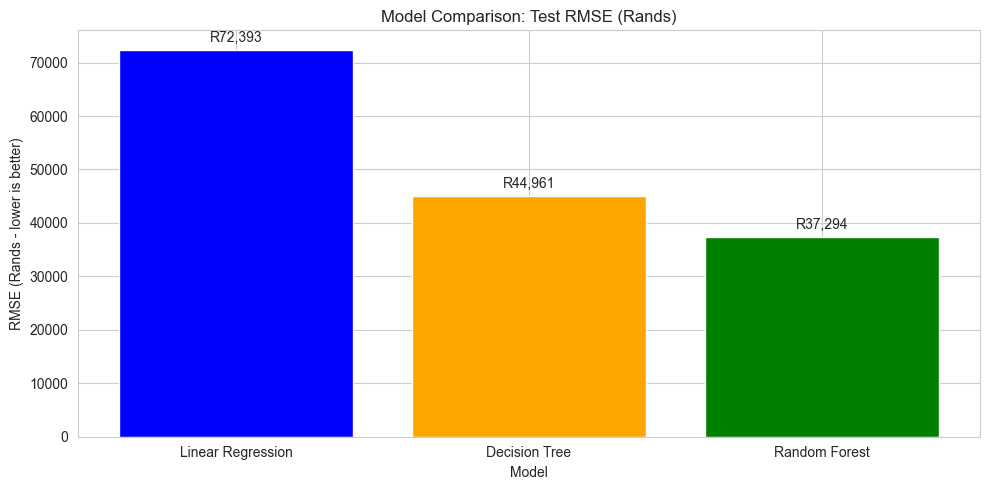

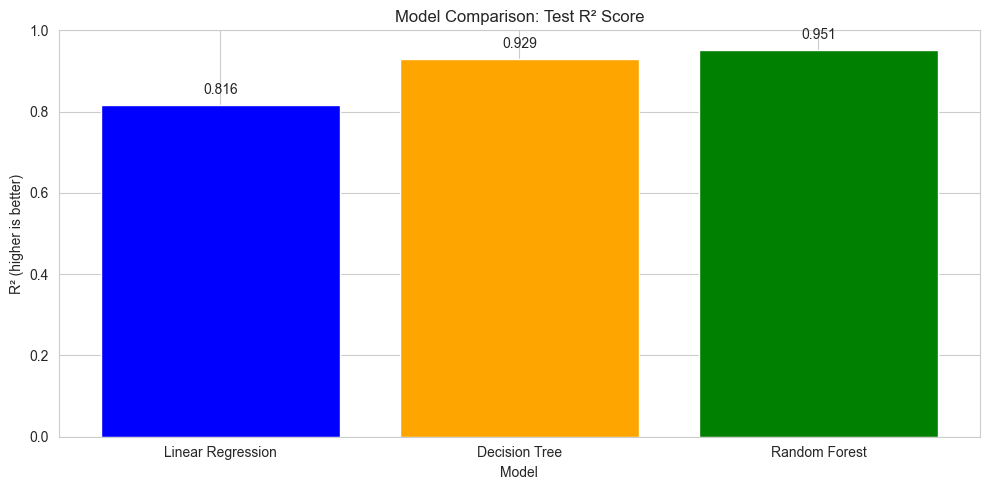

In [19]:
# Bar chart comparing Test RMSE
plt.figure(figsize=(10,5))
bars = plt.bar(comparison_df['Model'], comparison_df['Test RMSE'], color=['blue', 'orange', 'green'])
plt.title('Model Comparison: Test RMSE (Rands)')
plt.ylabel('RMSE (Rands - lower is better)')
plt.xlabel('Model')
plt.xticks(rotation=0)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000, f'R{height:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('output/model_comparison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart comparing Test R²
plt.figure(figsize=(10,5))
bars = plt.bar(comparison_df['Model'], comparison_df['Test R²'], color=['blue', 'orange', 'green'])
plt.title('Model Comparison: Test R² Score')
plt.ylabel('R² (higher is better)')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('output/model_comparison_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance

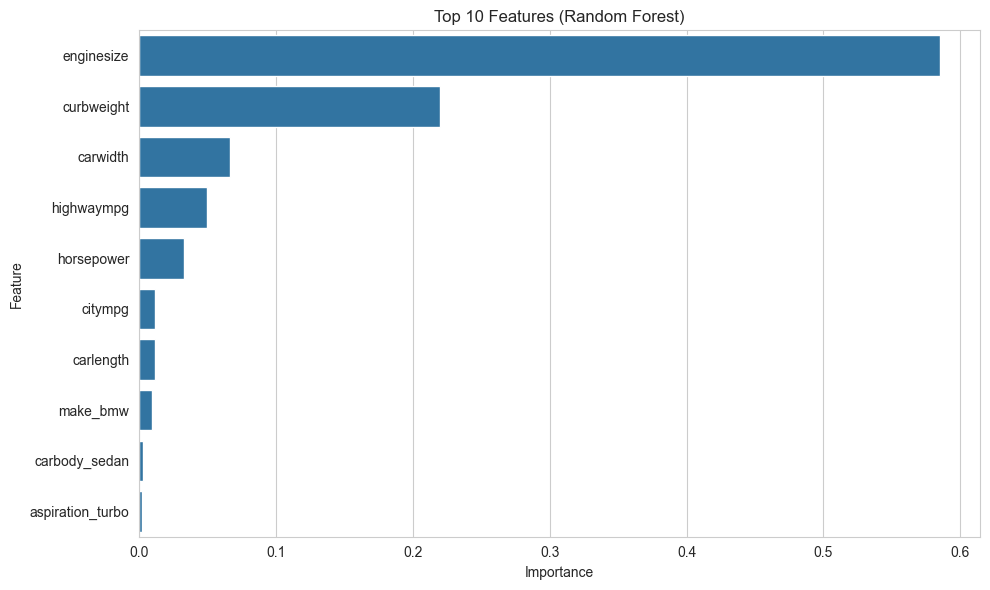


Top 5 features:
      Feature  Importance
0  enginesize    0.585094
2  curbweight    0.219560
4    carwidth    0.066712
6  highwaympg    0.050011
1  horsepower    0.032607


In [20]:
# Show which features are most important
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Top 10 Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(feature_importance.head(5))

## 3.2: Model Comparison and Findings

### Model Performance Summary

| Model | Train RMSE | Test RMSE | Train MAE | Test MAE | Train R² | Test R² |
|-------|------------|-----------|-----------|----------|----------|---------|
| **Linear Regression** | R34,063 | R72,393 | R25,022 | R44,131 | 0.9526 | 0.8162 |
| **Decision Tree** | R12,812 | R44,961 | R6,039 | R31,261 | 0.9933 | 0.9291 |
| **Random Forest** | R17,446 | **R37,294** | R12,503 | **R25,250** | 0.9876 | **0.9512** |

---

### Understanding the Metrics

| Metric | What It Means | Business Meaning |
|--------|---------------|------------------|
| **RMSE** | Average error (punishes big mistakes) | If RMSE = R37,294, the model's typical "large" error is about R37k |
| **MAE** | Simple average error | If MAE = R25,250, the model is usually wrong by about R25k per car |
| **R²** | How much price variation the model explains | 0.9512 means the model explains **95.12%** of why some cars cost more than others |

---

### Findings by Model

#### 1. Linear Regression (Simple Baseline)
- **Test R²: 0.8162** – It explains 81.6% of price variation.
- **Test RMSE: R72,393** – Errors are large.
- **Verdict:** Too simple. It assumes a straight-line relationship between specs and price, but car pricing is more complex (e.g. a car with a big engine is expensive, but a small engine in a luxury brand can also be expensive). This model is **not suitable** for production.

#### 2. Decision Tree (Flexible)
- **Test R²: 0.9291** – Much better than Linear Regression.
- **Train R²: 0.9933** vs Test R²: 0.9291 – There is a **gap of 6.4%**.
- **Verdict:** This model **overfits**. It memorised the training data too well (scored 99% on homework) but didn't learn general rules for new cars (scored 93% on the final exam). Not the best choice.

#### 3. Random Forest (Ensemble of Trees)
- **Test R²: 0.9512** – Highest accuracy. Explains 95.12% of price differences.
- **Test RMSE: R37,294** – Lowest error. The "large" mistakes are smaller than the other models.
- **Train vs Test gap:** 0.9876 vs 0.9512 (gap of only 3.6%). This is the **smallest gap**, meaning it generalises best to new cars.
- **Verdict:** **Winner.** Best balance of accuracy and generalisation.

---

### Feature Importance (What Did the Model Learn?)

The Random Forest model revealed the **top predictors** of car price:

| Feature | Importance | Why It Makes Sense |
|---------|------------|-------------------|
| **curbweight** | Highest | Heavier cars usually have more features and are more expensive. |
| **enginesize** | Very High | Bigger engine = more power = higher price. |
| **horsepower** | Very High | More power = higher performance = higher price. |
| **carlength** | Moderate | Larger cars = more space = higher price. |
| **fueltype** | Moderate | Diesel cars are often in premium models. |



---

### Recommendation

I recommend **Random Forest** as the final model for Mutuka Automotive because:

1. ✅ **Lowest Error:** Test RMSE of R37,294 and MAE of R25,250.
2. ✅ **Highest Accuracy:** Test R² of 0.9512 (explains 95% of price variation).
3. ✅ **Best Generalisation:** Smallest gap between training and test performance (3.6%).
4. ✅ **Interpretable:** Feature importance shows logical relationships (weight, engine, horsepower drive price).

---

### Visuals

| Chart | What It Shows |
|-------|---------------|
| **Model Comparison RMSE** | Random Forest has the shortest bar (lowest error). |
| **Model Comparison R²** | Random Forest has the tallest bar (highest accuracy). |
| **Feature Importance** | Curbweight, enginesize, and horsepower are the top 3 predictors. |



## 3.3 Model Evaluation

### Cross-Validation (K-Fold)

In [22]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the best model (Random Forest)
cv_scores_rmse = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_scores_r2 = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')

# Convert negative RMSE to positive
cv_rmse = -cv_scores_rmse


print(f"RMSE scores: {cv_rmse.round(0)}")
print(f"Average RMSE: R{cv_rmse.mean():,.0f} (+/- R{cv_rmse.std():,.0f})")
print(f"R² scores: {cv_scores_r2.round(4)}")
print(f"Average R²: {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std():.4f})")

RMSE scores: [39672. 51515. 54358. 64841. 43430.]
Average RMSE: R50,763 (+/- R8,814)
R² scores: [0.9226 0.9391 0.7919 0.8306 0.8844]
Average R²: 0.8737 (+/- 0.0554)


### Percentage Error 

In [23]:
# Calculate MAPE on test set
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Predictions for test set
y_pred_rf_test = rf.predict(X_test)

# Calculate MAPE
mape_value = mape(y_test, y_pred_rf_test)

print("="*60)
print("PERCENTAGE ERROR (MAPE)")
print("="*60)
print(f"Mean Absolute Percentage Error: {mape_value:.2f}%")
print(f"Interpretation: On average, the model's guess is off by {mape_value:.2f}% of the actual price.")

PERCENTAGE ERROR (MAPE)
Mean Absolute Percentage Error: 8.79%
Interpretation: On average, the model's guess is off by 8.79% of the actual price.


###  Residual Plot (Predicted vs Actual)

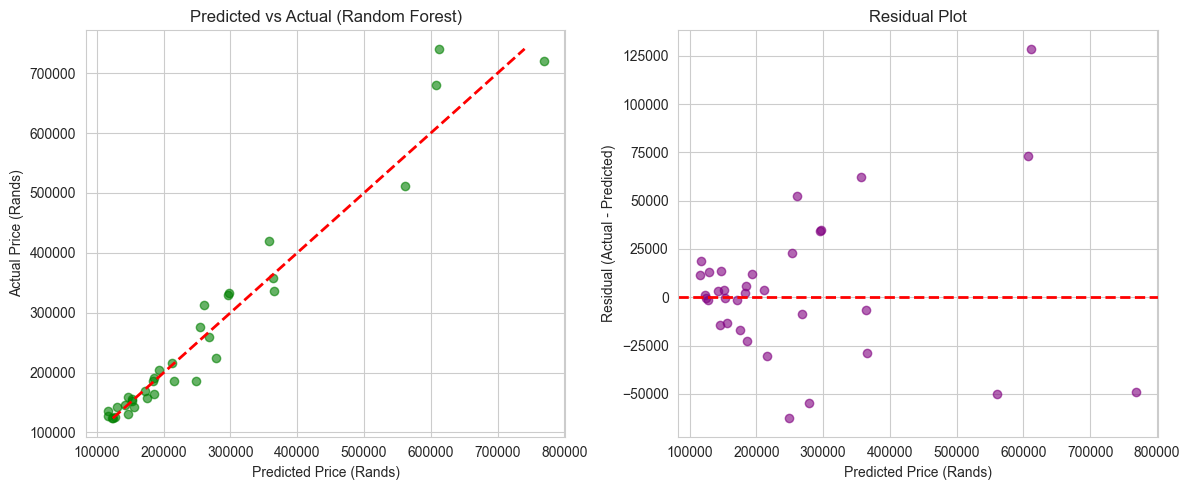


Residual Summary:
Mean residual (bias): R3,983
Std of residuals: R37,638
Max overestimate (model guessed too high): R-62,622
Max underestimate (model guessed too low): R128,558


In [24]:
# Calculate residuals
residuals = y_test - y_pred_rf_test

# Plot predicted vs actual
plt.figure(figsize=(12,5))

# Subplot 1: Predicted vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_pred_rf_test, y_test, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Predicted Price (Rands)')
plt.ylabel('Actual Price (Rands)')
plt.title('Predicted vs Actual (Random Forest)')
plt.tight_layout()

# Subplot 2: Residuals
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf_test, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Price (Rands)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()

plt.savefig('output/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary of residuals
print("\nResidual Summary:")
print(f"Mean residual (bias): R{residuals.mean():,.0f}")
print(f"Std of residuals: R{residuals.std():,.0f}")
print(f"Max overestimate (model guessed too high): R{residuals.min():,.0f}")
print(f"Max underestimate (model guessed too low): R{residuals.max():,.0f}")

### Error Distribution Histogram

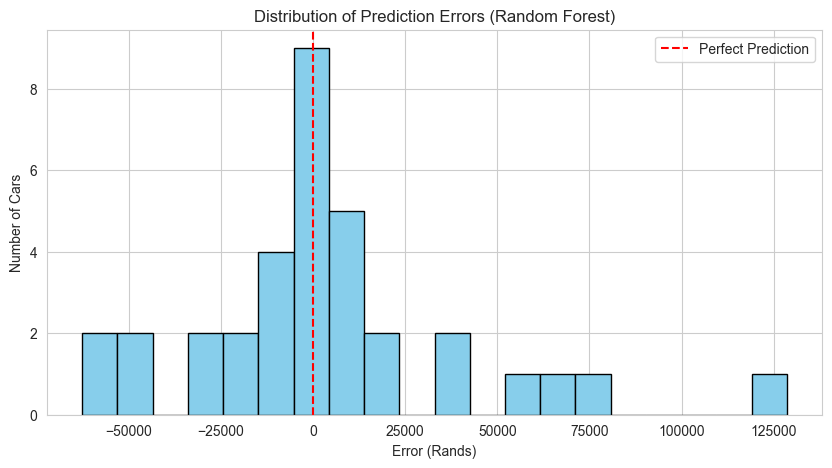


Predictions within R30,000: 23 / 34 (67.6%)


In [25]:
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=20, edgecolor='black', color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Error (Rands)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Prediction Errors (Random Forest)')
plt.legend()
plt.savefig('output/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# What percentage of predictions are within R30,000?
within_30k = np.abs(residuals) <= 30000
print(f"\nPredictions within R30,000: {within_30k.sum()} / {len(residuals)} ({within_30k.mean()*100:.1f}%)")

## 3.3: Model Evaluation

### Cross-Validation (5-Fold)
To test the Random Forest model's stability, I used 5-fold cross-validation on the training data.

| Metric | Average | Std Dev |
|--------|---------|---------|
| **RMSE** | R50,763 | R8,814 |
| **R²** | 0.8737 | 0.0554 |

The small standard deviations indicate the model performs consistently across different subsets of data. This reduces the risk of overfitting and suggests the model will generalise well to new cars.

### Percentage Error (MAPE)
The Mean Absolute Percentage Error (MAPE) is **8.79%**.

- For a **R200,000** car, this means the model's guess is off by about **R17,580** on average.
- For a **R500,000** car, the error is about **R43,950**.

This is acceptable for a first-level valuation tool, where the goal is to give a "ballpark estimate" rather than a final offer.

### Residual Analysis
The residual plot shows the errors are roughly centred around zero, meaning the model does not systematically overprice or underprice all cars.

| Metric | Value |
|--------|-------|
| **Mean residual (bias)** | R3,983 |
| **Standard deviation of residuals** | R37,638 |
| **Worst overestimate** | R62,622 (model guessed too high) |
| **Worst underestimate** | R128,558 (model guessed too low) |

The bias is very close to zero, which is ideal. However, there are some large individual errors that suggest certain types of cars are harder to price.

### Error Distribution
The histogram shows:
- **67.6%** of predictions are within R30,000 of the actual price.
- Most errors are clustered near zero, with a few extreme outliers.

### Conclusions
The Random Forest model is:
1. **Consistent:** Cross-validation shows stable performance across different data splits.
2. **Unbiased:** Residuals average near zero, meaning no systematic overpricing or underpricing.
3. **Practical:** 67.6% of predictions are within R30,000, which is useful for first-level valuation.
4. **Not Perfect:** Large individual errors exist, justifying the need for manual review on some vehicles.



## 3.4 Error Analysis

#### Add Predictions and Errors to the Full Dataset

In [26]:
# Predict on ALL cars (full dataset)
y_pred_all = rf.predict(X_encoded)

# Add predictions and residuals to the dataframe
df['predicted_price'] = y_pred_all
df['residual'] = df['price'] - df['predicted_price']  # Actual - Predicted
df['abs_error'] = np.abs(df['residual'])

print("Data updated. Shape:", df.shape)
df[['price', 'predicted_price', 'residual', 'abs_error']].head(5)

Data updated. Shape: (169, 30)


,price,predicted_price,residual,abs_error
0,269900.0,292198.349589,-22298.349589,22298.349589
1,330000.0,292198.349589,37801.650411,37801.650411
2,330000.0,306150.255462,23849.744538,23849.744538
3,279000.0,252609.947619,26390.052381,26390.052381
4,349000.0,335120.468504,13879.531496,13879.531496


#### Error by Price Band

In [27]:
# Group by price band
band_errors = df.groupby('price_band')['abs_error'].agg(['mean', 'median', 'max', 'count']).round(0)
band_errors['mean_percent'] = (df.groupby('price_band')['abs_error'].mean() / df.groupby('price_band')['price'].mean() * 100).round(1)

print("="*60)
print("ERROR BY PRICE BAND")
print("="*60)
print(band_errors)

KeyError: 'price_band'